# Evaluate structures and sequences versus sequences only

In this notebook, we assess the benefit of including the structural maps to training performance of the machine learning model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.metrics import roc_auc_score

In [2]:
SIGNIFICANCE_LEVEL = 0.05

In [3]:
model_types = ('', 'sequence_only')
data_splits = ('random', 'peptide', 'pMHC')

In [4]:
predictions = []
for data_split in data_splits:
    sequences = pd.read_csv(f'data/interim/sequences_{data_split}_split.csv', index_col='index')

    for model_type in model_types:
        prediction = pd.read_csv(
            f"data/processed/TCRStructMap_{model_type + '_' if model_type else model_type}predictions_on_sequences_"
            f'{data_split}_split.csv'
        )

        prediction['data_split'] = data_split
        prediction['model_type'] = model_type

        prediction = prediction.merge(sequences, how='left', left_on='index', right_index=True)
        prediction = prediction[prediction['sub_model_number'] == prediction['fold']].reset_index(drop=True)

        predictions.append(prediction)

predictions = pd.concat(predictions).reset_index(drop=True)

In [5]:
overall_roc_auc = predictions.groupby(['data_split', 'model_type']).apply(
    lambda group: roc_auc_score(group['label'], group['prediction']), include_groups=False
)
overall_roc_auc.name = 'roc_auc_score'

overall_roc_auc = overall_roc_auc.reindex(
    pd.MultiIndex.from_product(
        [data_splits, model_types],
        names=['data_split', 'model_type'],
    )
)

overall_roc_auc

data_split  model_type   
random                       0.876085
            sequence_only    0.892229
peptide                      0.666831
            sequence_only    0.682325
pMHC                         0.471265
            sequence_only    0.457763
Name: roc_auc_score, dtype: float64

In [6]:
NUM_SAMPLES = 25
SAMPLE_SIZE = 500

indices = predictions['index'].unique()
rng = np.random.default_rng(123)

samples_metric_scores = []
for sample_num in range(1, NUM_SAMPLES + 1):
    sample_indices = rng.choice(indices, SAMPLE_SIZE)

    sample = predictions[predictions['index'].isin(sample_indices)]

    for (data_split, model_type), group in sample.groupby(['data_split', 'model_type'], dropna=False):
        score = roc_auc_score(group['label'], group['prediction'])
        samples_metric_scores.append(
            {
                'sample_num': sample_num,
                'data_split': data_split,
                'model_type': model_type,
                'roc_auc_score': score,
            }
        )

samples_metric_scores = pd.DataFrame(samples_metric_scores)

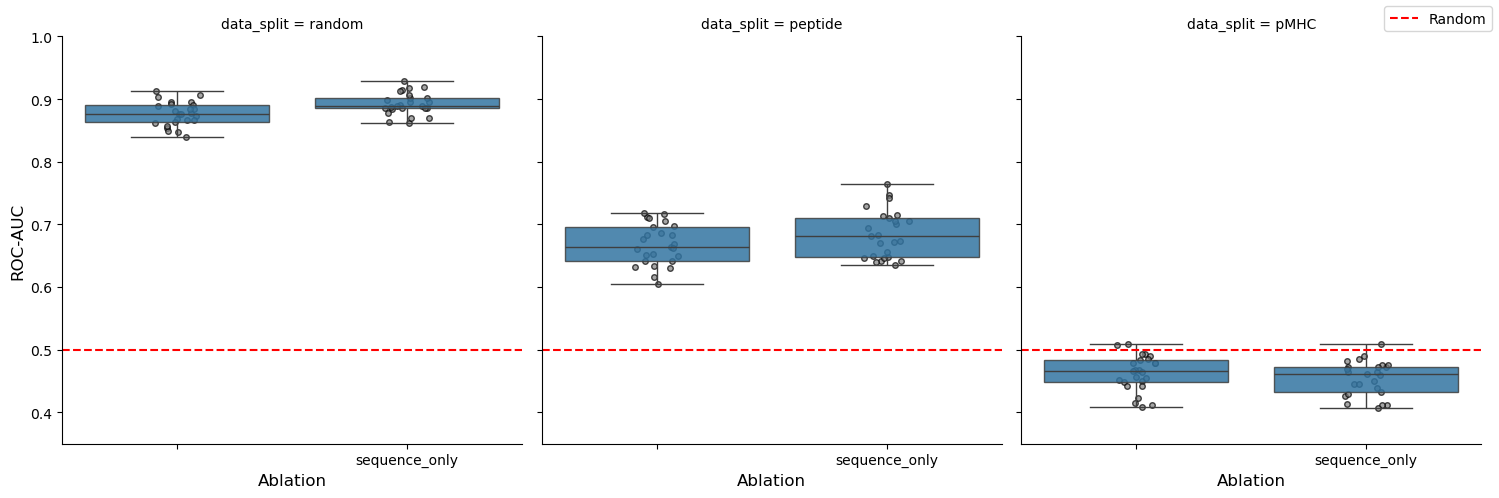

In [7]:
grid = sns.FacetGrid(samples_metric_scores, col='data_split', col_order=data_splits, sharex=False, height=5)

grid.map_dataframe(
    sns.boxplot,
    x='model_type',
    y='roc_auc_score',
    order=model_types,
    showfliers=False,
    boxprops={'alpha': 0.85},
    zorder=1,
)
grid.map_dataframe(
    sns.stripplot,
    x='model_type',
    y='roc_auc_score',
    order=model_types,
    color='grey',
    marker='o',
    size=4,
    edgecolor='black',
    linewidth=1,
    alpha=0.70,
    zorder=0,
)

grid.refline(y=0.5, color='red')
refline_handle = Line2D([0], [0], color='red', linestyle='--', label='Random')
grid.figure.legend(handles=[refline_handle], loc='upper right')

grid.set(ylim=(0.35, 1.0))
grid.set_axis_labels('Ablation', 'ROC-AUC', fontsize=12)

plt.savefig('report/figures/evaluate_structure_vs_sequence.svg')
plt.show()

In [8]:
metric_scores_agg = pd.concat(
    [
        overall_roc_auc,
        samples_metric_scores.groupby(['data_split', 'model_type'])['roc_auc_score']
        .agg(['std'])
        .sort_index(ascending=False),
    ],
    axis=1,
)

norm_val = stats.norm.ppf(1 - SIGNIFICANCE_LEVEL / 2)
metric_scores_agg['ci'] = metric_scores_agg.apply(
    lambda row, norm_val=norm_val: (
        row['roc_auc_score'] - norm_val * row['std'],
        row['roc_auc_score'] + norm_val * row['std'],
    ),
    axis=1,
)

metric_scores_agg = metric_scores_agg.reindex(
    pd.MultiIndex.from_product(
        [data_splits, model_types],
        names=['data_split', 'model_type'],
    )
)

metric_scores_agg

roc_auc_score       std  \
data_split model_type                               
random                         0.876085  0.019209   
           sequence_only       0.892229  0.017349   
peptide                        0.666831  0.032473   
           sequence_only       0.682325  0.037848   
pMHC                           0.471265  0.028396   
           sequence_only       0.457763  0.027444   

                                                                ci  
data_split model_type                                               
random                    (0.8384358432460358, 0.9137340200255891)  
           sequence_only  (0.8582265065022856, 0.9262322473531306)  
peptide                    (0.6031860937066418, 0.730476027153012)  
           sequence_only  (0.6081442548513021, 0.7565065117813004)  
pMHC                      (0.4156106231659526, 0.5269193794332403)  
           sequence_only  (0.4039735416001672, 0.5115523703944519)

In [9]:
def calculate_differences(df: pd.DataFrame) -> pd.DataFrame:
    groups = list(df.groupby('model_type'))
    groups = sorted(groups, key=lambda item: model_types.index(item[0]))

    differences = {
        'group_name_i': [],
        'group_name_j': [],
        'difference_roc_auc': [],
    }
    for i, (group_name_i, group_i) in enumerate(groups[:-1]):
        for group_name_j, group_j in groups[i + 1 :]:
            differences['difference_roc_auc'].append(
                group_i['roc_auc_score'].iloc[0] - group_j['roc_auc_score'].iloc[0]
            )

            differences['group_name_i'].append(group_name_i)
            differences['group_name_j'].append(group_name_j)

    return pd.DataFrame(differences).set_index(['group_name_i', 'group_name_j'])

In [10]:
overall_roc_auc_difference = (
    overall_roc_auc.reset_index().groupby('data_split').apply(calculate_differences, include_groups=False)
)

samples_metric_scores_differences = (
    samples_metric_scores.groupby(['sample_num', 'data_split'])
    .apply(calculate_differences, include_groups=False)
    .groupby(['data_split', 'group_name_i', 'group_name_j'])
    .agg(['std'])
)
samples_metric_scores_differences.columns = ['_'.join(column) for column in samples_metric_scores_differences.columns]


metric_scores_difference = pd.concat([overall_roc_auc_difference, samples_metric_scores_differences], axis=1)


norm_value = stats.t.ppf((2 - SIGNIFICANCE_LEVEL) / 2, NUM_SAMPLES - 1)
metric_scores_difference['ci'] = metric_scores_difference.apply(
    lambda row, norm_value=norm_value: (
        row['difference_roc_auc'] - norm_value * row['difference_roc_auc_std'],
        row['difference_roc_auc'] + norm_value * row['difference_roc_auc_std'],
    ),
    axis=1,
)

metric_scores_difference = metric_scores_difference.sort_index(
    level='data_split', key=lambda index: index.map(data_splits.index)
)

metric_scores_difference

,,,difference_roc_auc,difference_roc_auc_std,ci
data_split,group_name_i,group_name_j,,,
random,,sequence_only,-0.016144,0.014872,"(-0.046838524379897106, 0.01454963379610585)"
peptide,,sequence_only,-0.015494,0.026153,"(-0.06947203749491836, 0.03848339172196967)"
pMHC,,sequence_only,0.013502,0.024680,"(-0.03743556794987, 0.06443965855444375)"


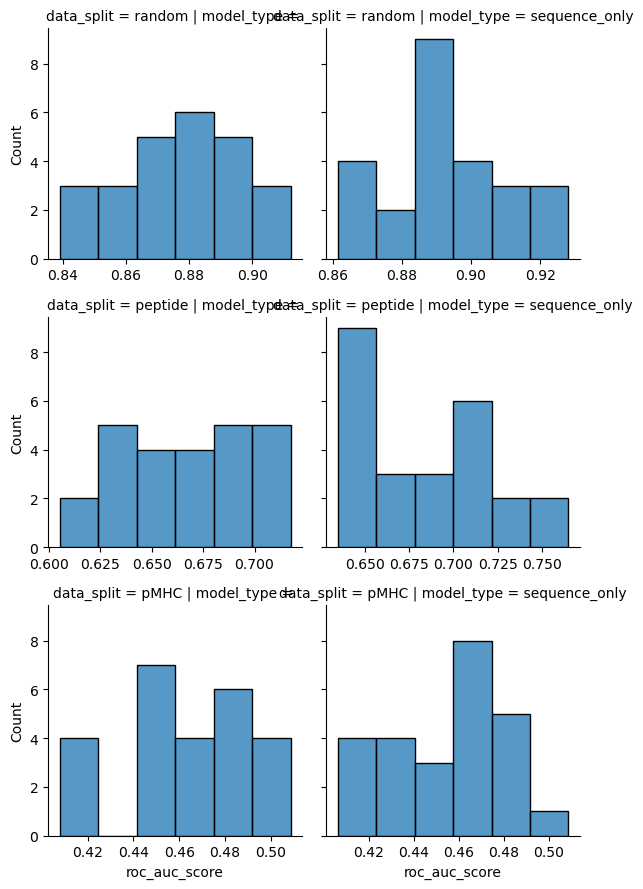

In [11]:
grid = sns.FacetGrid(
    samples_metric_scores,
    row='data_split',
    col='model_type',
    row_order=data_splits,
    col_order=model_types,
    sharex=False,
)
grid.map_dataframe(sns.histplot, x='roc_auc_score')

plt.show()

In [12]:
for data_split, data_group in samples_metric_scores.set_index('sample_num').sort_index().groupby('data_split'):
    print(data_split)
    print(
        stats.ttest_rel(
            data_group.query("model_type == ''")['roc_auc_score'],
            data_group.query("model_type == 'sequence_only'")['roc_auc_score'],
            alternative='greater',
        )
    )

    print()

pMHC
TtestResult(statistic=np.float64(1.6618312042572743), pvalue=np.float64(0.05477749789027123), df=np.int64(24))

peptide
TtestResult(statistic=np.float64(-3.1994976567218476), pvalue=np.float64(0.9980773200957815), df=np.int64(24))

random
TtestResult(statistic=np.float64(-5.46004320840954), pvalue=np.float64(0.999993485175593), df=np.int64(24))

